In [1]:
import sys
import nilearn
import os
from nilearn import datasets


In [2]:
import os
import glob
import numpy as np
import pandas as pd
import re
#读取 Excel 表格
csv_path = r"C:\Users\28439\Desktop\ASD\abide_data\ABIDE_pcp\Phenotypic_V1_0b_preprocessed1.csv"
phenotype_df = pd.read_csv(csv_path)
#找到所有的 .1D 脑区数据文件
folder_path = r'C:\Users\28439\Desktop\ASD\abide_data\ABIDE_pcp\cpac\nofilt_noglobal'
file_list = glob.glob(os.path.join(folder_path, '*.1D'))

#开始循环(核心部分)
# 准备两个空列表，用来装对应成功的“数据”和“标签”。数据就是脑区矩阵，标签就是是不是ASD。1为确诊，2为否
matched_all_time_series = []
matched_labels = []
success_count = 0
fail_count = 0

for file_path in file_list:
    filename = os.path.basename(file_path)

    # 使用正则表达式匹配文件名中的连续数字（这里的name都是 5到7 位数字）
    match = re.search(r'\d{5,7}', filename)

    if match:
        # 提取出匹配到的数字字符串
        sub_id_str = match.group()
        sub_id = int(sub_id_str)
    else:
        print(f"无法从文件名中提取数字 ID: {filename}")
        continue

    # 去 Excel查找
    subject_row = phenotype_df[phenotype_df['SUB_ID'] == sub_id]

    if not subject_row.empty:
        time_series = np.loadtxt(file_path)
        label = subject_row['DX_GROUP'].values[0]

        matched_all_time_series.append(time_series)
        matched_labels.append(label)
        success_count += 1
    else:
        fail_count += 1
        print(f"影像 ID {sub_id} ({filename}) 在 Excel 中未找到记录")

print(f"结束。成功: {success_count} 个，失败: {fail_count} 个。")

结束。成功: 871 个，失败: 0 个。


In [3]:
matched_all_time_series[1]

array([[  5.546286,   7.282161,   2.907049, ...,   9.950551, -26.025467,
         -0.65704 ],
       [  2.54021 ,  13.471737,   3.730662, ...,   8.499904, -17.060169,
        -24.378888],
       [ 11.905664,  11.730264,  10.500932, ...,  17.850127,  -9.002754,
         13.498619],
       ...,
       [  8.377427,  16.154781,   4.118375, ...,  19.136207,  48.605153,
         44.877876],
       [ 23.639163,  21.621997,   7.97641 , ...,  37.963332,  17.32928 ,
        -57.619307],
       [  7.984225,  -0.49954 ,  -5.297367, ...,  13.055218, -35.066465,
         39.980126]], shape=(146, 116))

In [4]:
print(matched_labels[1])

1


In [5]:
matched_all_time_series[23].shape

(316, 116)

### 这样的矩阵还不能用。现在是时间序列关于脑区的矩阵，维度不同，无法丢进cuda训练。

### 但我们可以通过np内置的皮尔逊指数算出FC，这样就又是一个116,116的图矩阵了

In [6]:
for i in range(0,871):
    matched_all_time_series[i] = np.corrcoef(matched_all_time_series[i],rowvar=False)
    matched_all_time_series[i] = np.nan_to_num(matched_all_time_series[i])

C:\Users\28439\miniconda3\envs\mri_env\lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\28439\miniconda3\envs\mri_env\lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


### 打好标签了，数据也和表格的都能一一对应，接下来开始搭建DNN来训练

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#检验一下是不是搬到GPU了
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"当前使用的训练设备: {device}")

当前使用的训练设备: cuda


## 先从简单的做起，根据脑电图预测是否患病。这是个二分类问题，损失函数是BCE LOSS，可以处理01标签，分类的DX_GROUP标签是12，所以需要在导入训练集和测试集的时候修改一下原数据的1,2标签即可。

### 1.初步处理导入数据到pytorch

In [8]:
print("正在导入数据")
X = np.array(matched_all_time_series)
y = np.array(matched_labels)

if np.any(y == 2):
    y[y==2] = 0#2对应没患病
#和图的邻接矩阵一样，这里只需要道路116*116矩阵的上半部分就行，因为是完全对称的，可以节约资源，节省时间
if(len(X.shape) == 3) and X.shape[1] == 116 and X.shape[2] == 116:
    triu_indices = np.triu_indices(116,k = 1)
    X_features = np.array([mat[triu_indices]for mat in X])
else :
    raise ValueError("维度没对齐，应该是871,116,116")
X_train,X_test,y_train,y_test = train_test_split(X_features,y,test_size=0.3,stratify=y,random_state=42)


正在导入数据


### 标准化数据然后变成Tensor送进去训练。真实训练的时候需要标准化，因为数据之间的偏差会很大，在算权重的时候会有bias。

### 机器学习里的regularization？都是防止过拟合的

In [9]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train).unsqueeze(1)
X_test_t = torch.FloatTensor(X_test)
y_test_t = torch.FloatTensor(y_test).unsqueeze(1)

In [10]:
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    drop_last=True
)

### 开始定义DNN模型

In [11]:
class DNN(nn.Module):
    def __init__(self,input_dim):
        super(DNN,self).__init__()
        self.network = nn.Sequential(
            #Layer_1
            nn.Linear(input_dim,512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),
             # Layer 2
            nn.Linear(512, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Layer 3
            nn.Linear(128, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            # Output Layer (二分类)
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.network(x)
    #实例化并且搬到GPU训练
model = DNN(input_dim=6670).to(device)

### 二叉熵损失函数，优化器就用Adam就行

In [12]:
criterion = nn.BCELoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-3)

### 开始训练循环

### 老熟人了，训练三部曲：训练，损失，反向传播优化

In [13]:
epochs = 50

train_loss_history = []
test_acc_history = []

for epoch in range(epochs):
    model.train()
    e_loss = 0.0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        output = model(batch_X)
        loss = criterion(output, batch_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        e_loss += loss.item() * batch_X.size(0)

    total_train_loss = e_loss / len(train_loader.dataset)
    train_loss_history.append(total_train_loss)

    model.eval()
    with torch.no_grad():
        X_test_cuda = X_test_t.to(device)
        y_test_cuda = y_test_t.to(device)

        test_outputs = model(X_test_cuda)
        preds = (test_outputs >= 0.5).float()
        correct = (preds == y_test_cuda).sum().item()
        accuracy = correct / len(y_test)

        test_acc_history.append(accuracy * 100)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {total_train_loss:.4f} | Test Acc: {accuracy*100:.2f}%")

Epoch [1/50] | Train Loss: 0.6851 | Test Acc: 57.63%
Epoch [5/50] | Train Loss: 0.3431 | Test Acc: 64.12%
Epoch [10/50] | Train Loss: 0.1854 | Test Acc: 62.98%
Epoch [15/50] | Train Loss: 0.1082 | Test Acc: 63.36%
Epoch [20/50] | Train Loss: 0.0957 | Test Acc: 65.65%
Epoch [25/50] | Train Loss: 0.0978 | Test Acc: 63.36%
Epoch [30/50] | Train Loss: 0.0661 | Test Acc: 63.36%
Epoch [35/50] | Train Loss: 0.0433 | Test Acc: 60.31%
Epoch [40/50] | Train Loss: 0.0441 | Test Acc: 63.36%
Epoch [45/50] | Train Loss: 0.0224 | Test Acc: 64.12%
Epoch [50/50] | Train Loss: 0.0491 | Test Acc: 65.27%


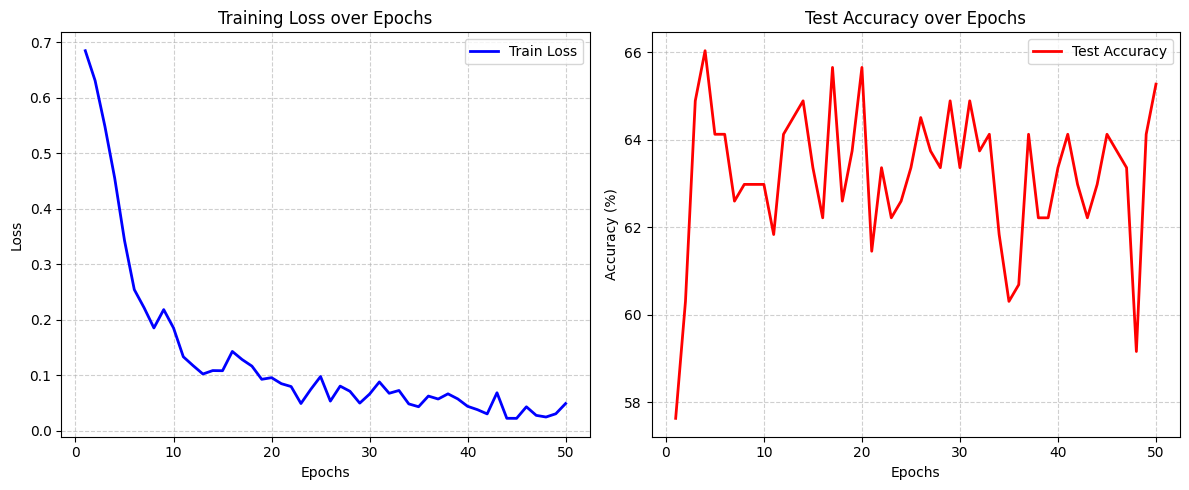

In [14]:
import matplotlib.pyplot as plt

# 设置绘图风格和大小
plt.figure(figsize=(12, 5))

# 1. 绘制 Loss 曲线
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), train_loss_history, label='Train Loss', color='blue', linewidth=2)
plt.title('Training Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# 2. 绘制 Accuracy 曲线
plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), test_acc_history, label='Test Accuracy', color='red', linewidth=2)
plt.title('Test Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()